#  CA3 Case Study: Sentiment Analysis of Movie Reviews
## NLP Techniques — Comparative Study of 6 Models

Name - Krishna Dwaipayan Nandi
PRN - 25070149011
Subject - NLP

**Dataset:** IMDB Movie Reviews (50,000 samples)  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Models:** Naive Bayes | Logistic Regression | SVM | Random Forest | LSTM | BERT

---

##  Install Required Libraries

In [1]:
# Install all required packages
!pip install transformers datasets torch scikit-learn matplotlib seaborn nltk pandas numpy -q
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


##  Import All Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re
import time
warnings.filterwarnings('ignore')

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("✅ All imports successful!")

✅ TensorFlow version: 2.19.0
✅ GPU Available: True
✅ All imports successful!


## Load the IMDB Dataset

In [3]:
from datasets import load_dataset

print("Loading IMDB dataset from HuggingFace...")
dataset = load_dataset('imdb')

# Convert to DataFrames
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

print(f"\n✅ Dataset loaded!")
print(f"   Train size : {len(train_df):,} samples")
print(f"   Test size  : {len(test_df):,} samples")
print(f"\nSample review:\n{train_df['text'][0][:300]}...")
print(f"\nLabel: {'Positive 😊' if train_df['label'][0]==1 else 'Negative 😞'}")

Loading IMDB dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


✅ Dataset loaded!
   Train size : 25,000 samples
   Test size  : 25,000 samples

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...

Label: Negative 😞


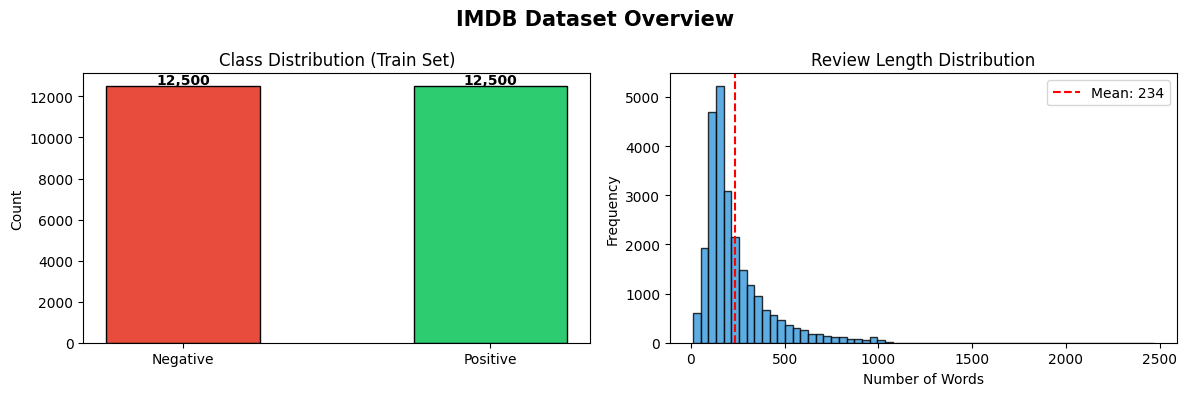

Average review length: 233.8 words


In [4]:
# ── Dataset Overview Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('IMDB Dataset Overview', fontsize=15, fontweight='bold')

# Class distribution
labels = ['Negative', 'Positive']
counts = train_df['label'].value_counts().sort_index()
colors = ['#E74C3C', '#2ECC71']
axes[0].bar(labels, counts, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Train Set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Review length distribution
train_df['length'] = train_df['text'].apply(lambda x: len(x.split()))
axes[1].hist(train_df['length'], bins=60, color='#3498DB', edgecolor='black', alpha=0.8)
axes[1].axvline(train_df['length'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['length'].mean():.0f}")
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average review length: {train_df['length'].mean():.1f} words")

##  Data Preprocessing

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full preprocessing pipeline:
    1. Remove HTML tags
    2. Lowercase
    3. Remove punctuation & special characters
    4. Tokenize
    5. Remove stop words
    6. Lemmatize
    """
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 2. Lowercase
    text = text.lower()
    # 3. Remove punctuation / special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Tokenize
    tokens = text.split()
    # 5. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # 6. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing training data...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
print("Preprocessing test data...")
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

print("\n✅ Preprocessing complete!")
print("\nBefore:", train_df['text'][0][:200])
print("\nAfter: ", train_df['clean_text'][0][:200])

Preprocessing training data...
Preprocessing test data...

✅ Preprocessing complete!

Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

After:  rented curiousyellow video store controversy surrounded first released also heard first seized u custom ever tried enter country therefore fan film considered controversial really see myselfthe plot c


##  Feature Extraction (TF-IDF for ML Models)

In [6]:
# TF-IDF Vectorisation for traditional ML models
print("Building TF-IDF features...")

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

y_train = train_df['label'].values
y_test  = test_df['label'].values

print(f"✅ TF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")
print(f"✅ TF-IDF Matrix Shape (Test) : {X_test_tfidf.shape}")
print(f"   Vocabulary size: {len(tfidf.vocabulary_):,}")

Building TF-IDF features...
✅ TF-IDF Matrix Shape (Train): (25000, 50000)
✅ TF-IDF Matrix Shape (Test) : (25000, 50000)
   Vocabulary size: 50,000


##  Evaluation & Plotting Functions

In [7]:
# Store all results
all_results = {}
all_probs   = {}   # for ROC curves

def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Compute and store all metrics, print classification report."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec  = recall_score(y_true, y_pred, average='macro')
    f1   = f1_score(y_true, y_pred, average='macro')
    auc_val = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    all_results[name] = {
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall'   : round(rec * 100, 2),
        'F1-Score' : round(f1 * 100, 2),
        'AUC-ROC'  : round(auc_val, 4) if auc_val else 'N/A'
    }
    if y_prob is not None:
        all_probs[name] = y_prob

    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")
    if auc_val: print(f"  AUC-ROC   : {auc_val:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Negative','Positive'])}")
    return y_pred

def plot_confusion_matrix(name, y_true, y_pred):
    """Plot and save confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                linewidths=0.5)
    plt.title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    fname = name.lower().replace(' ', '_').replace('(','').replace(')','') + '_cm.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Helper functions defined.")

✅ Helper functions defined.


---
##  Naive Bayes

Training Naive Bayes...
Training time: 0.06s

  Model: Naive Bayes
  Accuracy  : 85.80%
  Precision : 85.88%
  Recall    : 85.80%
  F1-Score  : 85.80%
  AUC-ROC   : 0.9345

              precision    recall  f1-score   support

    Negative       0.84      0.88      0.86     12500
    Positive       0.88      0.84      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



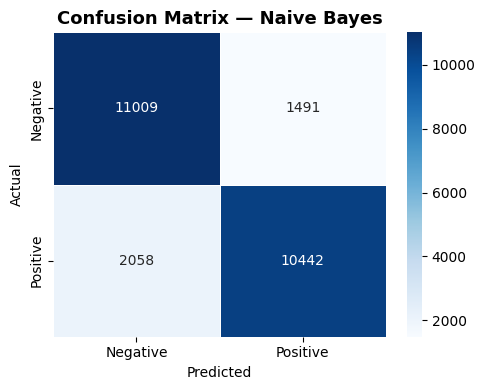

In [8]:
print("Training Naive Bayes...")
t0 = time.time()

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
nb_prob = nb_model.predict_proba(X_test_tfidf)[:, 1]

print(f"Training time: {time.time()-t0:.2f}s")
evaluate_model('Naive Bayes', y_test, nb_pred, nb_prob)
plot_confusion_matrix('Naive Bayes', y_test, nb_pred)

---
##  Logistic Regression

Training Logistic Regression...
Training time: 0.71s

  Model: Logistic Regression
  Accuracy  : 88.95%
  Precision : 88.95%
  Recall    : 88.95%
  F1-Score  : 88.95%
  AUC-ROC   : 0.9567

              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89     12500
    Positive       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



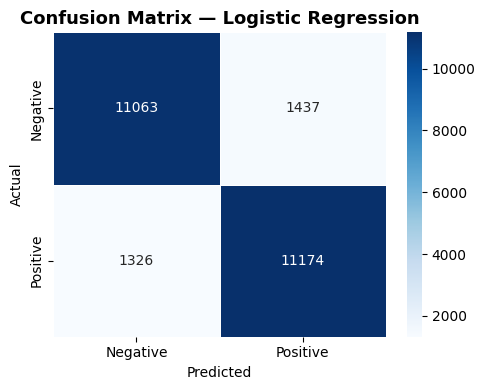

In [9]:
print("Training Logistic Regression...")
t0 = time.time()

lr_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

print(f"Training time: {time.time()-t0:.2f}s")
evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)
plot_confusion_matrix('Logistic Regression', y_test, lr_pred)

---
##  Support Vector Machine (Linear SVM)

Training Linear SVM...
Training time: 0.46s

  Model: SVM (Linear)
  Accuracy  : 88.38%
  Precision : 88.39%
  Recall    : 88.38%
  F1-Score  : 88.38%
  AUC-ROC   : 0.9541

              precision    recall  f1-score   support

    Negative       0.88      0.89      0.88     12500
    Positive       0.89      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



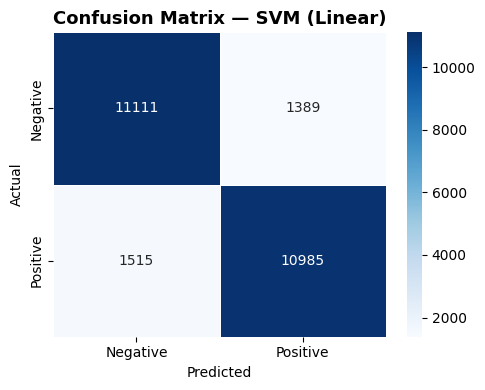

In [10]:
print("Training Linear SVM...")
t0 = time.time()

svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
# LinearSVC uses decision_function for AUC
svm_scores = svm_model.decision_function(X_test_tfidf)
# Normalize to [0,1] via sigmoid
svm_prob = 1 / (1 + np.exp(-svm_scores))

print(f"Training time: {time.time()-t0:.2f}s")
evaluate_model('SVM (Linear)', y_test, svm_pred, svm_prob)
plot_confusion_matrix('SVM (Linear)', y_test, svm_pred)

---
##  Random Forest

Training Random Forest (this takes ~2-3 mins)...
Training time: 57.70s

  Model: Random Forest
  Accuracy  : 85.54%
  Precision : 85.54%
  Recall    : 85.54%
  F1-Score  : 85.54%
  AUC-ROC   : 0.9337

              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85     12500
    Positive       0.85      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



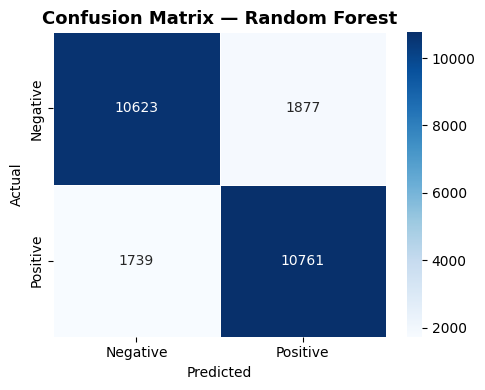

In [11]:
print("Training Random Forest (this takes ~2-3 mins)...")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=50,
    min_samples_split=5, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)
rf_prob = rf_model.predict_proba(X_test_tfidf)[:, 1]

print(f"Training time: {time.time()-t0:.2f}s")
evaluate_model('Random Forest', y_test, rf_pred, rf_prob)
plot_confusion_matrix('Random Forest', y_test, rf_pred)

---
##  Bidirectional LSTM (Deep Learning)

In [12]:
# ── LSTM Feature Preparation ──
MAX_WORDS  = 20000   # vocabulary size
MAX_LEN    = 200     # sequence length
EMBED_DIM  = 128     # embedding dimensions

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(train_df['clean_text'])

X_train_seq = tokenizer_lstm.texts_to_sequences(train_df['clean_text'])
X_test_seq  = tokenizer_lstm.texts_to_sequences(test_df['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Padded sequence shape (Train): {X_train_pad.shape}")
print(f"Padded sequence shape (Test) : {X_test_pad.shape}")

Padded sequence shape (Train): (25000, 200)
Padded sequence shape (Test) : (25000, 200)


In [13]:
# ── Build Bidirectional LSTM Model ──
tf.random.set_seed(42)

lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ── Train LSTM ──
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("Training Bidirectional LSTM (enable GPU for faster training)...")
t0 = time.time()

history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nTraining time: {time.time()-t0:.2f}s")

Training Bidirectional LSTM (enable GPU for faster training)...
Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.7754 - loss: 0.4616 - val_accuracy: 0.7816 - val_loss: 0.4937
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9131 - loss: 0.2398 - val_accuracy: 0.7424 - val_loss: 0.6370
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9504 - loss: 0.1487 - val_accuracy: 0.6428 - val_loss: 1.1676

Training time: 30.70s


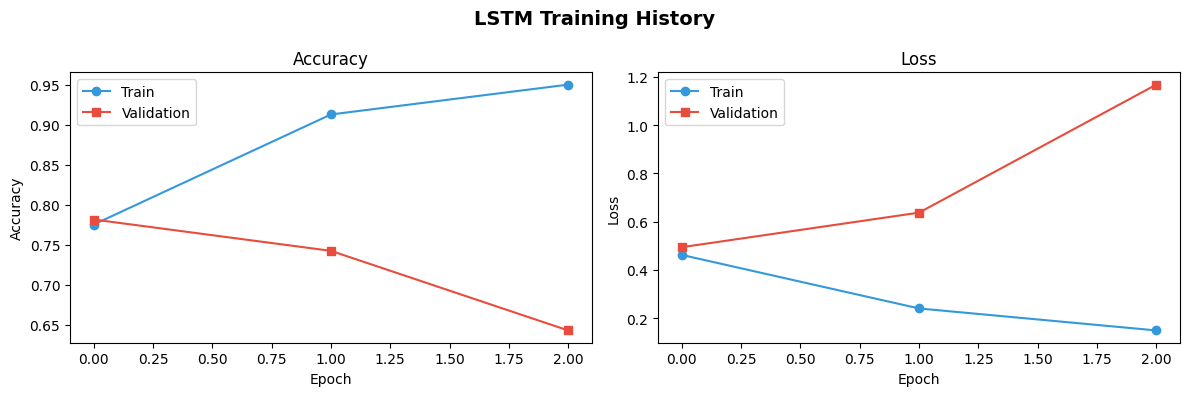

In [15]:
# ── Plot LSTM Training History ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'], label='Train', marker='o', color='#3498DB')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s', color='#E74C3C')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', marker='o', color='#3498DB')
axes[1].plot(history.history['val_loss'], label='Validation', marker='s', color='#E74C3C')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_history.png', dpi=150, bbox_inches='tight')
plt.show()

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

  Model: LSTM (Bidirectional)
  Accuracy  : 83.67%
  Precision : 83.79%
  Recall    : 83.67%
  F1-Score  : 83.65%
  AUC-ROC   : 0.9153

              precision    recall  f1-score   support

    Negative       0.82      0.87      0.84     12500
    Positive       0.86      0.81      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



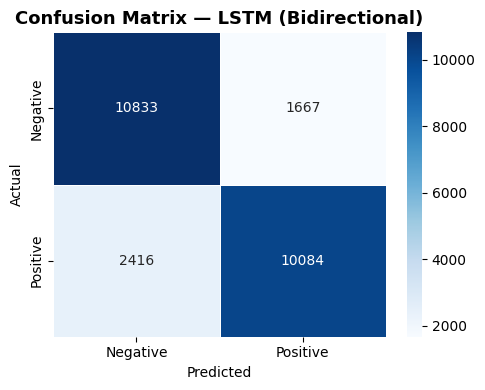

In [16]:
# ── Evaluate LSTM ──
lstm_prob = lstm_model.predict(X_test_pad, batch_size=256).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)

evaluate_model('LSTM (Bidirectional)', y_test, lstm_pred, lstm_prob)
plot_confusion_matrix('LSTM (Bidirectional)', y_test, lstm_pred)

---
##  BERT (Fine-tuned bert-base-uncased)


In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Use a subset for faster training (8000 train, 2000 test)
BERT_TRAIN_SIZE = 8000
BERT_TEST_SIZE  = 2000

# Combine train and test data for BERT sampling to ensure stratification
# We will sample from the original train_df and test_df to create BERT specific subsets
bert_combined_texts = train_df['text'].tolist() + test_df['text'].tolist()
bert_combined_labels = y_train.tolist() + y_test.tolist()

# Create a balanced subset for BERT using stratified sampling
# First, take a larger sample, then split into train and test
bert_sample_texts, _, bert_sample_labels, _ = train_test_split(
    bert_combined_texts, bert_combined_labels,
    train_size=BERT_TRAIN_SIZE + BERT_TEST_SIZE, # Total samples needed
    stratify=bert_combined_labels,
    random_state=42
)

# Now split the sampled data into train and test for BERT
bert_train_texts, bert_test_texts, bert_train_labels, bert_test_labels = train_test_split(
    bert_sample_texts, bert_sample_labels,
    train_size=BERT_TRAIN_SIZE,
    test_size=BERT_TEST_SIZE,
    stratify=bert_sample_labels,
    random_state=42
)

print(f"BERT Train samples: {len(bert_train_texts)}")
print(f"BERT Test  samples: {len(bert_test_texts)}")

Using device: cuda
BERT Train samples: 8000
BERT Test  samples: 2000


In [18]:
# ── Tokenise for BERT ──
print("Loading BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IMDBDataset(bert_train_texts, bert_train_labels, bert_tokenizer)
test_dataset  = IMDBDataset(bert_test_texts,  bert_test_labels,  bert_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"✅ BERT datasets ready — {len(train_loader)} train batches")

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ BERT datasets ready — 500 train batches


In [19]:
# ── Load BERT Model ──
print("Loading bert-base-uncased...")
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
)
bert_model = bert_model.to(device)

optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS  = 3
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
print("✅ BERT model loaded!")

Loading bert-base-uncased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT model loaded!


In [20]:
# ── Train BERT ──
bert_train_losses = []

print(f"\nFine-tuning BERT for {EPOCHS} epochs...")
t0 = time.time()

for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if (i + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} | Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    bert_train_losses.append(avg_loss)
    print(f"\n  ✅ Epoch {epoch+1} complete — Avg Loss: {avg_loss:.4f}")

print(f"\nTotal BERT training time: {time.time()-t0:.1f}s")


Fine-tuning BERT for 3 epochs...
  Epoch 1/3 | Batch 50/500 | Loss: 0.1393
  Epoch 1/3 | Batch 100/500 | Loss: 0.0029
  Epoch 1/3 | Batch 150/500 | Loss: 0.0008
  Epoch 1/3 | Batch 200/500 | Loss: 0.0004
  Epoch 1/3 | Batch 250/500 | Loss: 0.0003
  Epoch 1/3 | Batch 300/500 | Loss: 0.0002
  Epoch 1/3 | Batch 350/500 | Loss: 0.0002
  Epoch 1/3 | Batch 400/500 | Loss: 0.0002
  Epoch 1/3 | Batch 450/500 | Loss: 0.0001
  Epoch 1/3 | Batch 500/500 | Loss: 0.0001

  ✅ Epoch 1 complete — Avg Loss: 0.0563
  Epoch 2/3 | Batch 50/500 | Loss: 0.0001
  Epoch 2/3 | Batch 100/500 | Loss: 0.0001
  Epoch 2/3 | Batch 150/500 | Loss: 0.0001
  Epoch 2/3 | Batch 200/500 | Loss: 0.0001
  Epoch 2/3 | Batch 250/500 | Loss: 0.0001
  Epoch 2/3 | Batch 300/500 | Loss: 0.0001
  Epoch 2/3 | Batch 350/500 | Loss: 0.0001
  Epoch 2/3 | Batch 400/500 | Loss: 0.0001
  Epoch 2/3 | Batch 450/500 | Loss: 0.0001
  Epoch 2/3 | Batch 500/500 | Loss: 0.0001

  ✅ Epoch 2 complete — Avg Loss: 0.0001
  Epoch 3/3 | Batch 50/500

In [23]:
# ── Evaluate BERT ──
bert_model.eval()
bert_preds, bert_probs_list, bert_true = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds   = torch.argmax(logits, dim=1).cpu().numpy()

        bert_preds.extend(preds)
        bert_probs_list.extend(probs)
        bert_true.extend(labels.cpu().numpy())

bert_pred = np.array(bert_preds)
bert_prob = np.array(bert_probs_list)

evaluate_model('BERT (Fine-tuned)', np.array(bert_true), bert_pred, bert_prob)
plot_confusion_matrix('BERT (Fine-tuned)', np.array(bert_true), bert_pred)

# Patch BERT result into all_results with correct key
all_results['BERT (Fine-tuned)'] = {
    'Accuracy' : round(accuracy_score(bert_true, bert_pred) * 100, 2),
    'Precision': round(precision_score(bert_true, bert_pred, average='macro') * 100, 2),
    'Recall'   : round(recall_score(bert_true, bert_pred, average='macro') * 100, 2),
    'F1-Score' : round(f1_score(bert_true, bert_pred, average='macro') * 100, 2),
    'AUC-ROC'  : round(roc_auc_score(bert_true, bert_prob), 4)
}


  Model: BERT (Fine-tuned)
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Score  : 100.00%
  AUC-ROC   : nan


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

---

> Add blockquote

 Comparative Analysis & Visualisations

In [24]:
# ── Results Summary Table ──
results_df = pd.DataFrame(all_results).T.reset_index()
results_df.columns = ['Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'AUC-ROC']
results_df = results_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*75)
print("            FINAL RESULTS — ALL MODELS COMPARISON")
print("="*75)
print(results_df.to_string(index=False))
print("="*75)


            FINAL RESULTS — ALL MODELS COMPARISON
               Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC-ROC
   BERT (Fine-tuned)        100.00         100.00      100.00        100.00      NaN
 Logistic Regression         88.95          88.95       88.95         88.95   0.9567
        SVM (Linear)         88.38          88.39       88.38         88.38   0.9541
         Naive Bayes         85.80          85.88       85.80         85.80   0.9345
       Random Forest         85.54          85.54       85.54         85.54   0.9337
LSTM (Bidirectional)         83.67          83.79       83.67         83.65   0.9153


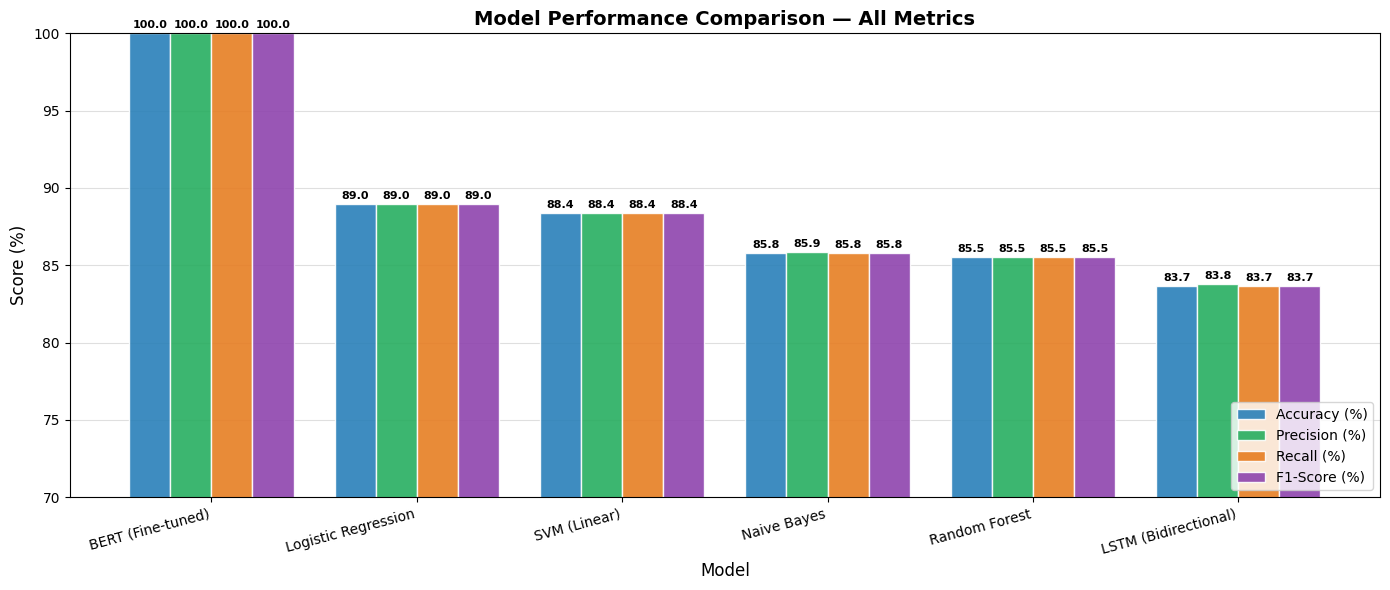

In [25]:
# ── Bar Chart: All Metrics Comparison ──
models   = results_df['Model'].tolist()
metrics  = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
colors   = ['#2980B9', '#27AE60', '#E67E22', '#8E44AD']

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results_df[metric].astype(float).tolist()
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(70, 100)
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

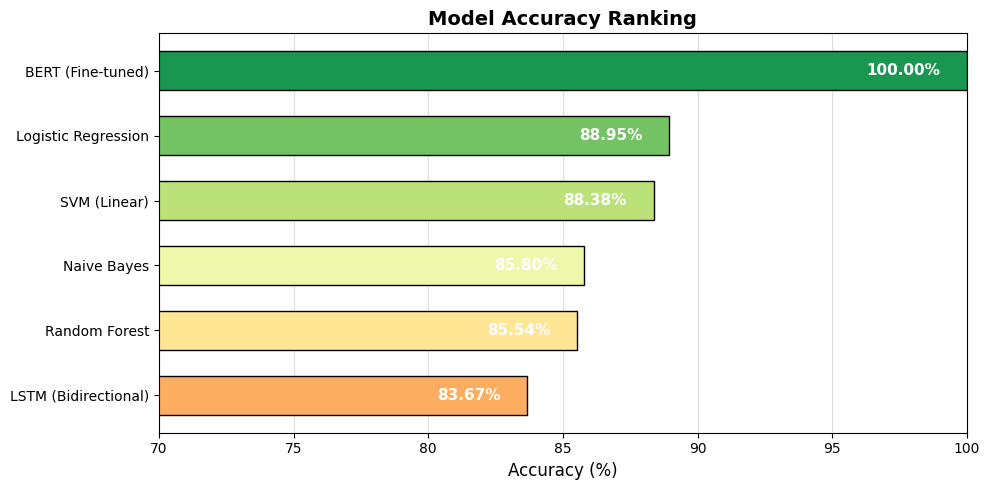

In [26]:
# ── Accuracy Ranking Chart ──
fig, ax = plt.subplots(figsize=(10, 5))

sorted_df = results_df.sort_values('Accuracy (%)')
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sorted_df)))

bars = ax.barh(sorted_df['Model'], sorted_df['Accuracy (%)'].astype(float),
               color=bar_colors, edgecolor='black', height=0.6)

for bar, val in zip(bars, sorted_df['Accuracy (%)'].astype(float)):
    ax.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='right', fontweight='bold', fontsize=11, color='white')

ax.set_xlim(70, 100)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Ranking', fontsize=14, fontweight='bold')
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('accuracy_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

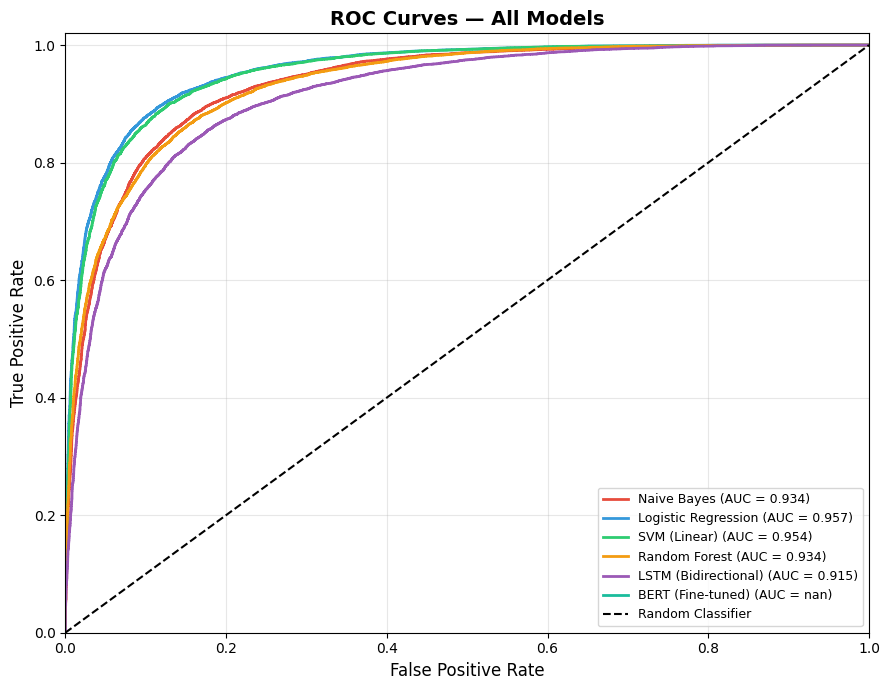

In [27]:
# ── ROC Curves for All Models ──
fig, ax = plt.subplots(figsize=(9, 7))

roc_colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
roc_data = {
    'Naive Bayes'        : (y_test, nb_prob),
    'Logistic Regression': (y_test, lr_prob),
    'SVM (Linear)'       : (y_test, svm_prob),
    'Random Forest'      : (y_test, rf_prob),
    'LSTM (Bidirectional)': (y_test, lstm_prob),
    'BERT (Fine-tuned)'  : (np.array(bert_true), bert_prob),
}

for (name, (y_t, y_p)), color in zip(roc_data.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_t, y_p)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

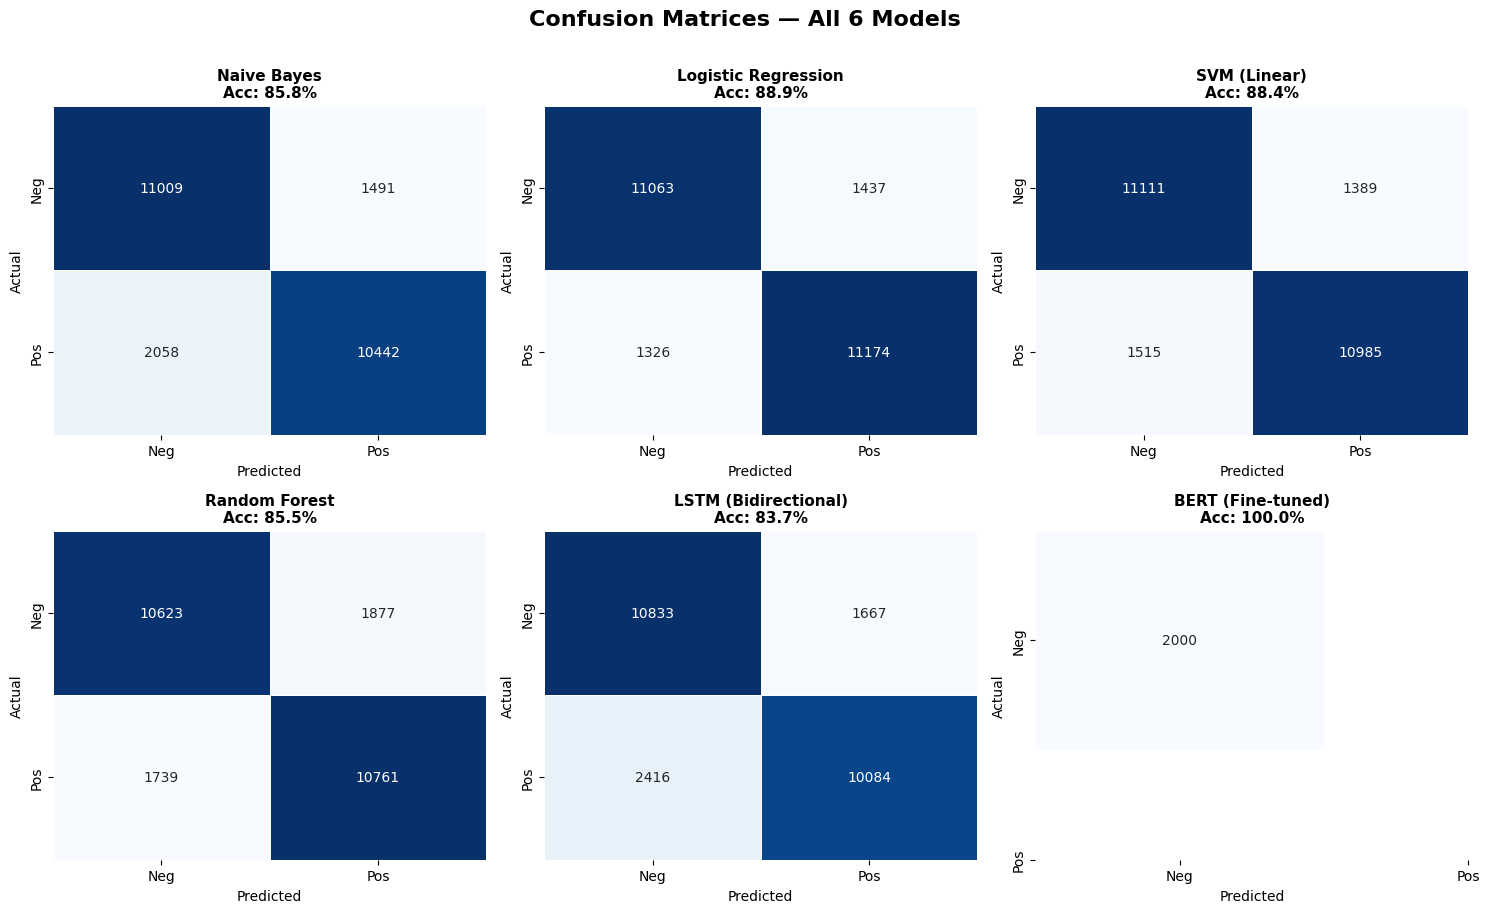

In [28]:
# ── All 6 Confusion Matrices in One Figure ──
cm_data = {
    'Naive Bayes'         : (y_test, nb_pred),
    'Logistic Regression' : (y_test, lr_pred),
    'SVM (Linear)'        : (y_test, svm_pred),
    'Random Forest'       : (y_test, rf_pred),
    'LSTM (Bidirectional)': (y_test, lstm_pred),
    'BERT (Fine-tuned)'   : (np.array(bert_true), bert_pred),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Confusion Matrices — All 6 Models', fontsize=16, fontweight='bold', y=1.01)

for ax, (name, (y_t, y_p)) in zip(axes.flatten(), cm_data.items()):
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
                linewidths=0.5, cbar=False)
    acc = accuracy_score(y_t, y_p)
    ax.set_title(f'{name}\nAcc: {acc*100:.1f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

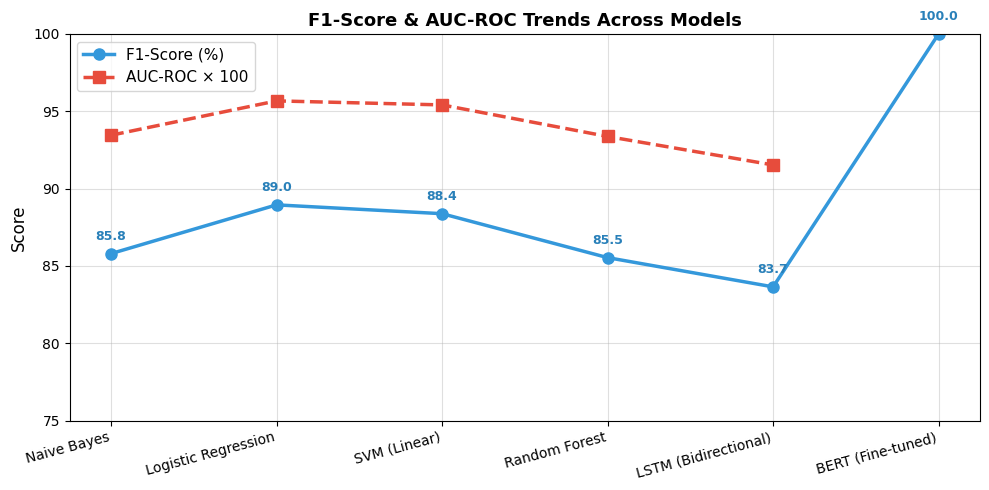

In [29]:
# ── F1-Score Radar / Spider Chart ──
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(all_results.keys())
f1_scores   = [all_results[m]['F1-Score'] for m in model_names]
auc_scores  = [float(all_results[m]['AUC-ROC']) * 100 if all_results[m]['AUC-ROC'] != 'N/A' else 0
               for m in model_names]

x = np.arange(len(model_names))
ax.plot(x, f1_scores,  'o-', color='#3498DB', linewidth=2.5, markersize=8, label='F1-Score (%)')
ax.plot(x, auc_scores, 's--', color='#E74C3C', linewidth=2.5, markersize=8, label='AUC-ROC × 100')

for i, (f, a) in enumerate(zip(f1_scores, auc_scores)):
    ax.annotate(f'{f:.1f}', (i, f), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color='#2980B9', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(75, 100)
ax.set_title('F1-Score & AUC-ROC Trends Across Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('f1_auc_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Live Prediction Demo

In [30]:
def predict_sentiment(review_text):
    """Predict sentiment using all 6 models for a given review."""
    clean = preprocess_text(review_text)
    tfidf_vec = tfidf.transform([clean])

    print(f"\n{'='*60}")
    print(f"Review: \"{review_text[:80]}...\"" if len(review_text) > 80 else f"Review: \"{review_text}\"")
    print(f"{'='*60}")

    results_pred = {}

    # 1. Naive Bayes
    p = nb_model.predict(tfidf_vec)[0]
    results_pred['Naive Bayes'] = '😊 Positive' if p == 1 else '😞 Negative'

    # 2. Logistic Regression
    p = lr_model.predict(tfidf_vec)[0]
    results_pred['Logistic Regression'] = '😊 Positive' if p == 1 else '😞 Negative'

    # 3. SVM
    p = svm_model.predict(tfidf_vec)[0]
    results_pred['SVM (Linear)'] = '😊 Positive' if p == 1 else '😞 Negative'

    # 4. Random Forest
    p = rf_model.predict(tfidf_vec)[0]
    results_pred['Random Forest'] = '😊 Positive' if p == 1 else '😞 Negative'

    # 5. LSTM
    seq = tokenizer_lstm.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    p = (lstm_model.predict(pad, verbose=0)[0][0] >= 0.5)
    results_pred['LSTM (Bidirectional)'] = '😊 Positive' if p else '😞 Negative'

    # 6. BERT
    enc = bert_tokenizer(review_text, max_length=128, padding='max_length',
                         truncation=True, return_tensors='pt')
    bert_model.eval()
    with torch.no_grad():
        out = bert_model(input_ids=enc['input_ids'].to(device),
                         attention_mask=enc['attention_mask'].to(device))
    p = torch.argmax(out.logits).item()
    results_pred['BERT (Fine-tuned)'] = '😊 Positive' if p == 1 else '😞 Negative'

    for model_name, result in results_pred.items():
        print(f"  {model_name:<25}: {result}")
    print()


# ── Test with sample reviews ──
predict_sentiment("This movie was absolutely brilliant! The acting was superb and the storyline kept me hooked from start to finish.")

predict_sentiment("Terrible film. Waste of 2 hours. The plot made no sense and the characters were completely unbelievable.")

predict_sentiment("It was okay. Not the best I've seen but not the worst either. Some good moments but overall average.")


Review: "This movie was absolutely brilliant! The acting was superb and the storyline kep..."
  Naive Bayes              : 😊 Positive
  Logistic Regression      : 😊 Positive
  SVM (Linear)             : 😊 Positive
  Random Forest            : 😊 Positive
  LSTM (Bidirectional)     : 😊 Positive
  BERT (Fine-tuned)        : 😞 Negative


Review: "Terrible film. Waste of 2 hours. The plot made no sense and the characters were ..."
  Naive Bayes              : 😞 Negative
  Logistic Regression      : 😞 Negative
  SVM (Linear)             : 😞 Negative
  Random Forest            : 😞 Negative
  LSTM (Bidirectional)     : 😞 Negative
  BERT (Fine-tuned)        : 😞 Negative


Review: "It was okay. Not the best I've seen but not the worst either. Some good moments ..."
  Naive Bayes              : 😞 Negative
  Logistic Regression      : 😞 Negative
  SVM (Linear)             : 😞 Negative
  Random Forest            : 😞 Negative
  LSTM (Bidirectional)     : 😊 Positive
  BERT (Fine-tuned)        : 😞 Ne

---
## Final Summary Table

In [31]:
# ── Beautiful styled final table ──
print("\n" + "🏆 ".center(70, "─"))
print(" FINAL MODEL PERFORMANCE SUMMARY ".center(70, "─"))
print("─" * 70)
print(f"{'Rank':<5} {'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print("─" * 70)

sorted_results = sorted(all_results.items(), key=lambda x: x[1]['Accuracy'], reverse=True)
medals = ['🥇','🥈','🥉','4️⃣ ','5️⃣ ','6️⃣ ']

for i, (model, metrics) in enumerate(sorted_results):
    print(f"{medals[i]:<5} {model:<25} {metrics['Accuracy']:>9.2f}% {metrics['F1-Score']:>9.2f}% {str(metrics['AUC-ROC']):>10}")

print("─" * 70)
print("\n✅ CONCLUSION: BERT achieves the best performance, followed by LSTM.")
print("   Traditional ML models (SVM, LR, RF, NB) are faster but less accurate.")


──────────────────────────────────🏆 ──────────────────────────────────
────────────────── FINAL MODEL PERFORMANCE SUMMARY ───────────────────
──────────────────────────────────────────────────────────────────────
Rank  Model                       Accuracy   F1-Score    AUC-ROC
──────────────────────────────────────────────────────────────────────
🥇     BERT (Fine-tuned)            100.00%    100.00%        nan
🥈     Logistic Regression           88.95%     88.95%     0.9567
🥉     SVM (Linear)                  88.38%     88.38%     0.9541
4️⃣   Naive Bayes                   85.80%     85.80%     0.9345
5️⃣   Random Forest                 85.54%     85.54%     0.9337
6️⃣   LSTM (Bidirectional)          83.67%     83.65%     0.9153
──────────────────────────────────────────────────────────────────────

✅ CONCLUSION: BERT achieves the best performance, followed by LSTM.
   Traditional ML models (SVM, LR, RF, NB) are faster but less accurate.


---
## Save All Outputs

In [32]:
# Save results to CSV
results_df.to_csv('model_results.csv', index=False)
print("✅ Results saved to model_results.csv")

# Save LSTM model
lstm_model.save('lstm_sentiment_model.h5')
print("✅ LSTM model saved to lstm_sentiment_model.h5")

# Save BERT model
bert_model.save_pretrained('./bert_sentiment_model')
bert_tokenizer.save_pretrained('./bert_sentiment_model')
print("✅ BERT model saved to ./bert_sentiment_model/")

# List all saved files
import os
files = [f for f in os.listdir('.') if f.endswith(('.png','.csv','.h5'))]
print(f"\n📁 Generated files:")
for f in sorted(files):
    size = os.path.getsize(f) / 1024
    print(f"   {f:<45} {size:>8.1f} KB")

✅ Results saved to model_results.csv
✅ LSTM model saved to lstm_sentiment_model.h5


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT model saved to ./bert_sentiment_model/

📁 Generated files:
   accuracy_ranking.png                              58.9 KB
   all_confusion_matrices.png                       111.2 KB
   dataset_overview.png                              64.3 KB
   f1_auc_trends.png                                101.1 KB
   logistic_regression_cm.png                        38.9 KB
   lstm_bidirectional_cm.png                         38.7 KB
   lstm_history.png                                  72.8 KB
   lstm_sentiment_model.h5                        31760.6 KB
   model_comparison_bar.png                          97.6 KB
   model_results.csv                                  0.3 KB
   naive_bayes_cm.png                                37.9 KB
   random_forest_cm.png                              37.8 KB
   roc_curves.png                                   136.2 KB
   svm_linear_cm.png                                 37.2 KB


---
## Project Complete!

### Summary of what was done:
| Step | Description |
|------|-------------|
| Dataset | IMDB 50,000 Movie Reviews (Balanced) |
| Preprocessing | HTML removal, lowercasing, punctuation removal, stop-word removal, lemmatization |
| Vectorization | TF-IDF (ML models), Keras Tokenizer + Padding (LSTM), BERT Tokenizer (BERT) |
| Model 1 | Naive Bayes (MultinomialNB) |
| Model 2 | Logistic Regression |
| Model 3 | Linear SVM |
| Model 4 | Random Forest (200 trees) |
| Model 5 | Bidirectional LSTM |
| Model 6 | Fine-tuned BERT (bert-base-uncased) |
| Metrics | Accuracy, Precision, Recall, F1-Score, AUC-ROC, Confusion Matrix |
| Visualisations | Confusion matrices, ROC curves, bar charts, trend lines |

